---
title: "Volatility Forecasts (Part 6 - STES to VolGRU Relaxation Ladder)"
date: 2026-03-05
description: "We formalize STES as a constrained one-dimensional GRU, verify exact reproduction, and report a controlled sequence of relaxations to a full VolGRU model on the Part 5 SPY setup."
categories: [Quantitative Finance, Volatility Modeling, Time Series]
content-type: "series"
series-id: "volatility-forecasting"
series-title: "Volatility Forecasts"
series-part: 6
project-ids: [volatility-forecasting]
format:
  html:
    toc: true
    code-fold: true
execute:
  echo: true
  warning: false
  message: false
  freeze: false
---


## Introduction

Part 5 held the data and feature design fixed and asked which predictors help STES-style volatility models. This post keeps that same empirical setup and asks a different question: what happens if we change the updating mechanism itself, while still keeping the latent volatility state one-dimensional?

The starting point is the STES model from earlier in the series. The endpoint is a scalar, or one-dimensional, VolGRU: a GRU-style updating rule in which the hidden state is just one number rather than a vector. The goal of the post is to show that these are not unrelated objects. STES can be written as a tightly restricted scalar GRU, and once that connection is made we can study a sequence of models that removes those restrictions one by one.

That sequence is what I call the model `ladder`. By `ladder`, I just mean an ordered list of models, where each new model changes exactly one piece of the previous one. By `relaxing` STES, I mean allowing one part of the STES update rule to become more flexible than before. The central questions are therefore: can a constrained scalar VolGRU reproduce STES exactly, which added degrees of freedom matter empirically, and do they improve forecasting enough to justify the extra complexity?

## GRU Primer

Because this post studies a one-dimensional VolGRU, it is clearer to write the GRU update directly in scalar form. Let $h_t$ be the scalar hidden state and let $u_t$ collect the observable inputs at time $t$. A scalar GRU uses three moving parts: an update gate $z_t$, a reset gate $r_t$, and a candidate state $\tilde h_t$. One convenient way to write the update is

$$
r_t = \sigma(w_r^\top u_t + u_r h_{t-1} + b_r),
$$

$$
z_t = \sigma(w_z^\top u_t + u_z h_{t-1} + b_z),
$$

$$
\tilde h_t = g\!\left(w_h^\top u_t + u_h r_t h_{t-1} + b_h\right),
$$

$$
h_t = (1-z_t) h_{t-1} + z_t \tilde h_t.
$$

The last line is the important one. The new state is a weighted average of the old state and the candidate state. If $z_t$ is near zero, the model mostly keeps the old state. If $z_t$ is near one, it moves strongly toward the candidate. The reset gate $r_t$ affects the candidate itself by controlling how strongly the old state enters that candidate.

For volatility forecasting, this structure should already feel familiar. STES also updates a running state by blending yesterday's forecast with today's new information through a time-varying weight. So before fitting anything, the right conceptual question is not `why bring in a GRU at all?` It is `how close is STES already to this scalar GRU update rule?`

## From STES to One-Dimensional GRU

Let $r_t$ denote daily log return and define $x_t = r_t^2$. In the notation used earlier in the series, the STES recursion is

$$
v_t = (1-\alpha_t) v_{t-1} + \alpha_t x_t,
$$

with gate

$$
\alpha_t = \sigma(\beta^\top \phi_{t-1}),
$$

where $v_t$ is the filtered variance state, $x_t$ is the new squared-return observation, and $\phi_{t-1}$ contains the lagged predictors that determine the gate. In this post, $\phi_{t-1}$ includes the augmented feature set carried over from Part 4.

Now compare that with the scalar GRU update

$$
h_t = (1-z_t) h_{t-1} + z_t \tilde h_t.
$$

These two equations have the same structure: both combine an old state with a new candidate using a time-varying weight. To recover STES from the scalar GRU form, impose the following identifications and restrictions:

1. Set the GRU state equal to the variance state: $h_t = v_t$.
2. Set the GRU update gate equal to the STES gate: $z_t = \alpha_t$.
3. Force the GRU candidate to be the raw squared return: $\tilde h_t = x_t = r_t^2$.
4. Keep the state one-dimensional and do not give the candidate an active reset-gate role.

Under those restrictions, the GRU update collapses exactly to the STES recursion. That is the key reason the connection matters: STES is not merely `inspired by` a GRU-style update. It can be written as a very specific scalar GRU with most of the GRU flexibility switched off.

This also explains what `relaxing` STES means in the rest of the post. A relaxation is just the removal of one of those restrictions. We can first let the candidate be learned instead of fixed at $r_t^2$. We can then let the update gate depend on the current state as well as observable features. We can then add reset behavior. Finally, we can replace the linear candidate map with a nonlinear one. The model sequence below follows exactly that path.

## STES-to-GRU Mapping at a Glance

The table below summarizes the scalar correspondence and shows what changes as we move from STES toward the fuller one-dimensional VolGRU specification studied in this post.

| STES object | Scalar GRU interpretation | What gets relaxed later? |
| --- | --- | --- |
| Variance state $v_t$ | Hidden state $h_t$ | The state remains one-dimensional throughout this post. |
| Gate $\alpha_t$ | Update gate $z_t$ | In $M3$, the gate is allowed to depend on the current state as well as observable features. |
| Squared return $x_t=r_t^2$ | Candidate state $\tilde h_t$ | In $M2$, the fixed candidate is replaced by a learned positive candidate. |
| No reset mechanism | Reset gate inactive | In $M4$, reset behavior is introduced. |
| Linear candidate restriction | Simple candidate map | In $M5$, the candidate becomes nonlinear. |

So if you want a one-line summary of the post, it is this: start from STES, rewrite it as a constrained scalar GRU update, and then remove those constraints one at a time to see which ones actually help forecasting.

In [1]:
#| echo: false
#| output: false

import gc
import os
import sys
import copy
import logging
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from dotenv import load_dotenv

# --- PATH SETUP ---
WORKSPACE_ROOT = Path('/Users/steveyang/Projects/Github')
BLOG_PATH = WORKSPACE_ROOT / 'steveya.github.io'
VF_PATH = WORKSPACE_ROOT / 'volatility-forecast'
AF_PATH = WORKSPACE_ROOT / 'alphaforge'

for p in (BLOG_PATH, VF_PATH, AF_PATH):
    if str(p) not in sys.path:
        sys.path.insert(0, str(p))

load_dotenv(VF_PATH / '.env')
logging.basicConfig(level=logging.ERROR)

SEED = 42
np.random.seed(SEED)

from IPython.display import display

from alphaforge.data.cache import FileCacheBackend
from volatility_forecast.pipeline import build_default_ctx
from volatility_forecast.evaluation.metrics import rmse, mae, qlike
from volatility_forecast.evaluation.dm_test import diebold_mariano

from volatility_forecast.model.stes_model import STESModel
from volatility_forecast.model.tree_stes_model import XGBoostSTESModel

from blog_styles import (
    style_results_table,
    inject_blog_table_css,
    apply_blog_plot_style,
    BLOG_PALETTE,
)

inject_blog_table_css()
apply_blog_plot_style()

SCRIPT_CACHE_DIR = VF_PATH / '.af_cache'
SCRIPT_CACHE_MODE = 'use'
cache = FileCacheBackend(SCRIPT_CACHE_DIR)
ctx = build_default_ctx(
    tiingo_api_key=os.environ.get('TIINGO_API') or os.environ.get('TIINGO_API_KEY'),
    tiingo_cache_backends=[cache],
    tiingo_cache_mode=SCRIPT_CACHE_MODE,
)

print(f'Tiingo cache dir: {SCRIPT_CACHE_DIR}')
print(f'Tiingo cache mode: {SCRIPT_CACHE_MODE}')

Tiingo cache dir: /Users/steveyang/Projects/Github/volatility-forecast/.af_cache
Tiingo cache mode: use


## Data and Empirical Setup

I keep the Part 4 protocol unchanged. The sample is SPY from January 2000 through December 2023, with a fixed split at row 4000. That way the train and test windows stay constant while only the model architecture changes.

Because the target is next-day squared return, the deterministic calendar and scheduled-event features are attached to the date being forecast. A row at date `t` is used to predict next-day variance, so it carries the known-ahead calendar and event labels for the next trading session `t+1`.

In [2]:
#| label: cache-preflight
#| code-fold: true
#| code-summary: "Cache-only preflight"

PARITY_TICKER = 'SPY'
PARITY_START = pd.Timestamp('2000-01-01', tz='UTC')
PARITY_END = pd.Timestamp('2023-12-31', tz='UTC')
PARITY_SPLIT_INDEX = 4000

parity_cache_key = f'{PARITY_TICKER}|adj=True'
parity_cached = cache.get(parity_cache_key)
if parity_cached is None or parity_cached.empty:
    raise RuntimeError(
        f'Cache-only mode: no cached data found for key={parity_cache_key} in {SCRIPT_CACHE_DIR}. '
        'Populate cache first; this notebook does not pull live Tiingo data.'
    )

print('Cache preflight OK:', parity_cache_key)


Cache preflight OK: SPY|adj=True


In [3]:
#| label: build-parity-dataset
#| code-fold: true
#| code-summary: "Build Part-4-parity SPY dataset"

from volatility_forecast.pipeline import build_vol_dataset, VolDatasetSpec
from alphaforge.features.dataset_spec import (
    UniverseSpec,
    TimeSpec,
    FeatureRequest,
    TargetRequest,
    JoinPolicy,
    MissingnessPolicy,
)
from volatility_forecast.features.return_features import (
    LagLogReturnTemplate,
    LagAbsLogReturnTemplate,
    LagSquaredLogReturnTemplate,
)
from volatility_forecast.targets.squared_return import NextDaySquaredReturnTarget


def build_dataset_spec_parity(source: str, ticker: str, start, end, lags: int) -> VolDatasetSpec:
    features = (
        FeatureRequest(
            template=LagLogReturnTemplate(),
            params={'lags': lags, 'source': source, 'table': 'market.ohlcv', 'price_col': 'close'},
        ),
        FeatureRequest(
            template=LagAbsLogReturnTemplate(),
            params={'lags': lags, 'source': source, 'table': 'market.ohlcv', 'price_col': 'close'},
        ),
        FeatureRequest(
            template=LagSquaredLogReturnTemplate(),
            params={'lags': lags, 'source': source, 'table': 'market.ohlcv', 'price_col': 'close'},
        ),
    )

    target = TargetRequest(
        template=NextDaySquaredReturnTarget(),
        params={'source': source, 'table': 'market.ohlcv', 'price_col': 'close', 'scale': 1.0},
        horizon=1,
        name='y',
    )

    return VolDatasetSpec(
        universe=UniverseSpec(entities=[ticker]),
        time=TimeSpec(start=start, end=end, calendar='XNYS', grid='B', asof=None),
        features=features,
        target=target,
        join_policy=JoinPolicy(how='inner', sort_index=True),
        missingness=MissingnessPolicy(final_row_policy='drop_if_any_nan'),
    )

spec_parity = build_dataset_spec_parity(
    source='tiingo',
    ticker=PARITY_TICKER,
    start=PARITY_START,
    end=PARITY_END,
    lags=0,
)

ctx_parity = build_default_ctx(
    tiingo_api_key=os.environ.get('TIINGO_API') or os.environ.get('TIINGO_API_KEY'),
    tiingo_cache_backends=[cache],
    tiingo_cache_mode='use',
)

X_raw, y_raw, r_raw, _ = build_vol_dataset(ctx_parity, spec_parity, persist=False)

if isinstance(X_raw.index, pd.MultiIndex):
    X_par = X_raw.xs(PARITY_TICKER, level='entity_id').sort_index().astype(float)
    y_par = y_raw.xs(PARITY_TICKER, level='entity_id').sort_index().astype(float)
    r_par = r_raw.xs(PARITY_TICKER, level='entity_id').sort_index().astype(float)
else:
    X_par = X_raw.sort_index().astype(float)
    y_par = y_raw.sort_index().astype(float)
    r_par = r_raw.sort_index().astype(float)

if 'const' not in X_par.columns:
    X_par['const'] = 1.0

common_idx = X_par.index.intersection(y_par.index).intersection(r_par.index)
X_par = X_par.loc[common_idx]
y_par = y_par.loc[common_idx]
r_par = r_par.loc[common_idx]

assert len(X_par) > PARITY_SPLIT_INDEX, f'Need > {PARITY_SPLIT_INDEX} rows, got {len(X_par)}'
assert X_par.index.min() >= PARITY_START
assert X_par.index.max() <= PARITY_END + pd.Timedelta(days=5)

print(f'Rows: {len(X_par)}')
print(f'Date range: {X_par.index.min().date()} -> {X_par.index.max().date()}')
print(f'Base columns: {list(X_par.columns)}')


Rows: 6035
Date range: 2000-01-04 -> 2023-12-28
Base columns: ['lag.logret.fc5d3612d9c7', 'lag.abslogret.1ad490bcb584', 'lag.sqlogret.c2cf3aa70c10', 'const']


In [25]:
#| label: build-augmented-features
#| code-fold: true
#| code-summary: "Construct augmented feature matrix and split"

import gc

from alphaforge.features import CalendarFlagsTemplate, EventDateTemplate
from alphaforge.features.template import SliceSpec as AFSliceSpec

# HAR-diff feature from the Part 4 parity dataset
rv_par = r_par ** 2
rv5_har = rv_par.rolling(5, min_periods=1).mean()
rv20_har = rv_par.rolling(20, min_periods=1).mean()
rv_diff_har = rv5_har - rv20_har

X_hdiff = X_par.copy()
X_hdiff['rv_diff_5_20'] = rv_diff_har.loc[X_hdiff.index].values

# Deterministic calendar and event features
cal_tmpl = CalendarFlagsTemplate()
cal_slice = AFSliceSpec(
    start=PARITY_START,
    end=PARITY_END,
    entities=[PARITY_TICKER],
)
cal_ff = cal_tmpl.transform(
    ctx_parity,
    params={
        'calendar': 'XNYS',
        'flags': ('dow', 'is_month_end', 'is_quarter_end', 'is_year_end'),
        'one_hot_dow': True,
    },
    slice=cal_slice,
    state=None,
)

evt_tmpl = EventDateTemplate()
evt_ff = evt_tmpl.transform(
    ctx_parity,
    params={'calendar': 'XNYS', 'events': ('fomc', 'opex', 'imm'), 'max_days': 30, 'near_window': 3},
    slice=cal_slice,
    state=None,
)

def _next_session_lookup_index(source_idx, target_idx):
    source_dates = pd.DatetimeIndex(source_idx).normalize()
    if source_dates.tz is not None:
        source_dates = source_dates.tz_convert(None)
    source_dates = pd.DatetimeIndex(source_dates.unique()).sort_values()

    target_dates = pd.DatetimeIndex(target_idx).normalize()
    if target_dates.tz is not None:
        target_dates = target_dates.tz_convert(None)

    positions = source_dates.searchsorted(target_dates, side='left')
    next_positions = positions + 1
    if np.any(next_positions >= len(source_dates)):
        raise ValueError('Cannot align seasonal features to forecast date: missing next session in source index.')

    return pd.DatetimeIndex(source_dates[next_positions])


def _extract_entity(ff, entity, target_idx, align_to='same_day'):
    df = ff.X.xs(entity, level='entity_id').sort_index()

    col_rename = {}
    for fid in df.columns:
        if fid in ff.catalog.index:
            col_rename[fid] = ff.catalog.loc[fid, 'transform']
        else:
            col_rename[fid] = fid
    df = df.rename(columns=col_rename)

    df_dates = df.index.normalize()
    if df_dates.tz is not None:
        df_dates = df_dates.tz_convert(None)
    df.index = df_dates

    target_dates = target_idx.normalize()
    if target_dates.tz is not None:
        target_dates = target_dates.tz_convert(None)

    if align_to == 'forecast_date':
        lookup_dates = _next_session_lookup_index(df.index, target_idx)
    elif align_to == 'same_day':
        lookup_dates = target_dates
    else:
        raise ValueError("align_to must be 'same_day' or 'forecast_date'")

    out = df.reindex(lookup_dates)
    out.index = target_idx
    return out.dropna(how='all')


def _add_period_end_lead_windows(cal_df, strict_cols, lead=3):
    lead_df = pd.DataFrame(index=cal_df.index)
    for strict_col in strict_cols:
        period_name = strict_col.replace('is_', '')
        lead_hits = sum(cal_df[strict_col].shift(-k).fillna(0.0) for k in range(1, lead + 1))
        lead_df[f'pre_{period_name}_{lead}d'] = (lead_hits > 0).astype(float)
    return pd.concat([cal_df, lead_df], axis=1)


cal_df = _extract_entity(cal_ff, PARITY_TICKER, X_hdiff.index, align_to='forecast_date')
strict_period_end_cols = ['is_month_end', 'is_quarter_end', 'is_year_end']
ordered_dow_cols = [c for c in cal_df.columns if c.startswith('dow_')]
cal_df = cal_df[ordered_dow_cols + strict_period_end_cols]
cal_df = _add_period_end_lead_windows(cal_df, strict_period_end_cols, lead=3)

evt_df = _extract_entity(evt_ff, PARITY_TICKER, X_hdiff.index, align_to='forecast_date')
seasonal_df = pd.concat([cal_df, evt_df], axis=1)

X_aug = X_hdiff.join(seasonal_df.loc[X_hdiff.index])

# Release intermediates before splitting to keep the notebook light.
del rv_par, rv5_har, rv20_har, rv_diff_har, X_hdiff
del cal_tmpl, cal_ff, evt_tmpl, evt_ff, cal_df, evt_df, seasonal_df
gc.collect()

X_tr = X_aug.iloc[:PARITY_SPLIT_INDEX]
X_te = X_aug.iloc[PARITY_SPLIT_INDEX:]
y_tr = y_par.iloc[:PARITY_SPLIT_INDEX]
y_te = y_par.iloc[PARITY_SPLIT_INDEX:]
r_tr = r_par.iloc[:PARITY_SPLIT_INDEX]
r_te = r_par.iloc[PARITY_SPLIT_INDEX:]

X_tr_s, X_te_s = scale_data_parity(X_tr, X_te)
X_all_s = pd.concat([X_tr_s, X_te_s])
y_all = pd.concat([y_tr, y_te])
r_all = pd.concat([r_tr, r_te])

actual_is = y_tr.values
actual_os = y_te.values

SCALE_FACTOR = 100.0
y_tr_scaled = y_tr * (SCALE_FACTOR ** 2)
r_tr_scaled = r_tr * SCALE_FACTOR
r_all_scaled = r_all * SCALE_FACTOR

print('Augmented features:', X_aug.shape[1])
print('Train rows:', len(X_tr_s), 'Test rows:', len(X_te_s))
print('Augmented columns example:', list(X_aug.columns)[:12])

Augmented features: 27
Train rows: 4000 Test rows: 2035
Augmented columns example: ['lag.logret.fc5d3612d9c7', 'lag.abslogret.1ad490bcb584', 'lag.sqlogret.c2cf3aa70c10', 'const', 'rv_diff_5_20', 'dow_0', 'dow_1', 'dow_2', 'dow_3', 'dow_4', 'dow_5', 'dow_6']


## Model Ladder Definitions

I will now compare an ordered sequence of models. This is what I mean by the model `ladder`: each rung starts from the previous model and changes one assumption, so we can see which extra flexibility is actually doing useful work.

$M0$ is the original STES benchmark. $M1$ is the constrained one-dimensional VolGRU written so that it should reproduce STES exactly under shared gate parameters. $M2$ keeps the STES gate but replaces the fixed candidate $x_t$ with a learned positive linear candidate. $M3$ lets the update gate depend on the current state as well as the observable features. $M4$ adds reset gating. $M5$ replaces the linear candidate with a small nonlinear positive candidate, giving the full VolGRU specification studied here.

So the point of the comparison is not to line up unrelated models under one table. It is to move from STES toward GRU one step at a time and ask which newly released assumption, if any, actually improves the forecast.

In [16]:
#| label: fit-baselines-stes-xgb
#| code-fold: true
#| code-summary: "Fit M0 STES and XGBSTES baseline on Part-4 features"
import time as _time

STES_L2_GRID = [
    {'l2_reg': 0.001},
    {'l2_reg': 0.01},
    {'l2_reg': 0.1},
]

XGB_PARAMS_PARITY = {
    'booster': 'gblinear',
    'updater': 'coord_descent',
    'max_depth': 5,
    'learning_rate': 0.01,
    'subsample': 1.0,
    'colsample_bytree': 1.0,
    'min_child_weight': 1.0,
    'reg_lambda': 1.0,
    'reg_alpha': 0.0,
    'verbosity': 0,
}
XGB_ROUNDS_PARITY = 100
GRID_E2E = [
    {'min_child_weight': 5.0, 'learning_rate': 0.05, 'max_depth': 3},
    {'min_child_weight': 20.0, 'learning_rate': 0.1, 'max_depth': 3},
    {'min_child_weight': 50.0, 'learning_rate': 0.05, 'max_depth': 2},
]

# M0: STES reference
print('Fitting STES CV (3 configs × 3 folds)...')
_t0 = _time.perf_counter()
stes_m0 = STESModel(random_state=SEED)
stes_m0.fit(
    X_tr_s,
    y_tr,
    returns=r_tr,
    perform_cv=True,
    cv_grid=STES_L2_GRID,
    cv_splits=3,
)
stes_sigma_all, stes_alpha_all = stes_m0.predict_with_alpha(X_all_s, returns=r_all)
print(f'  STES done in {_time.perf_counter() - _t0:.1f}s  (best l2_reg={stes_m0.l2_reg})')

# XGBSTES baseline (Algorithm 2)
print('Fitting XGBSTES CV (3 configs × 3 folds, 100 rounds)...')
_t0 = _time.perf_counter()
xgb_model = XGBoostSTESModel(
    xgb_params=XGB_PARAMS_PARITY,
    num_boost_round=XGB_ROUNDS_PARITY,
    fit_method='end_to_end',
    e2e_grad_hess_scale=1.0,
    e2e_debug=False,
    e2e_debug_print_once=False,
    random_state=SEED,
)
xgb_model.fit(
    X_tr_s,
    y_tr_scaled,
    returns=r_tr_scaled,
    perform_cv=True,
    cv_grid=GRID_E2E,
    cv_splits=3,
)

xgb_sigma_scaled_all = np.asarray(xgb_model.predict(X_all_s, returns=r_all_scaled), dtype=float)
xgb_sigma_all = xgb_sigma_scaled_all / (SCALE_FACTOR ** 2)
xgb_alpha_all = np.asarray(xgb_model.get_alphas(X_all_s), dtype=float)

print(f'  XGBSTES done in {_time.perf_counter() - _t0:.1f}s')
print('STES best l2_reg:', stes_m0.l2_reg)
print('XGB params after CV:', xgb_model.xgb_params)

Fitting STES CV (3 configs × 3 folds)...
  STES done in 4.5s  (best l2_reg=0.1)
Fitting XGBSTES CV (3 configs × 3 folds, 100 rounds)...
  XGBSTES done in 4.0s
STES best l2_reg: 0.1
XGB params after CV: {'booster': 'gblinear', 'updater': 'coord_descent', 'max_depth': 3, 'learning_rate': 0.1, 'subsample': 1.0, 'colsample_bytree': 1.0, 'min_child_weight': 20.0, 'reg_lambda': 1.0, 'reg_alpha': 0.0, 'verbosity': 0}


In [17]:
#| label: fit-volgru-ladder
#| code-fold: true
#| code-summary: "Fit M1-M5 VolGRU ladder (with CV for M2-M5)"

import torch
from volatility_forecast.model.volgru_model import VolGRUModel
from volatility_forecast.model.volgru_config import VolGRUConfig

torch.manual_seed(SEED)
torch.use_deterministic_algorithms(True, warn_only=True)
print('Torch version:', torch.__version__)

# CV grid: regularisation and learning-rate candidates
# Includes strong-regularisation configs to combat IS-OS gap
VOLGRU_CV_GRID = [
    # --- light regularisation ---
    {'lr': 1e-2, 'weight_decay_gate': 1e-4, 'weight_decay_candidate': 1e-4,
     'beta_stay_close_lambda': 1e-3, 'gate_entropy_lambda': 1e-3},
    {'lr': 1e-3, 'weight_decay_gate': 1e-4, 'weight_decay_candidate': 1e-4,
     'beta_stay_close_lambda': 1e-3, 'gate_entropy_lambda': 1e-3},
    # --- medium regularisation ---
    {'lr': 1e-2, 'weight_decay_gate': 1e-3, 'weight_decay_candidate': 1e-3,
     'beta_stay_close_lambda': 1e-2, 'gate_entropy_lambda': 1e-3},
    {'lr': 1e-3, 'weight_decay_gate': 1e-3, 'weight_decay_candidate': 1e-3,
     'beta_stay_close_lambda': 1e-2, 'gate_entropy_lambda': 1e-3},
    # --- strong regularisation ---
    {'lr': 1e-2, 'weight_decay_gate': 1e-2, 'weight_decay_candidate': 1e-2,
     'beta_stay_close_lambda': 5e-2, 'gate_entropy_lambda': 1e-2},
    {'lr': 1e-3, 'weight_decay_gate': 1e-2, 'weight_decay_candidate': 1e-2,
     'beta_stay_close_lambda': 1e-1, 'gate_entropy_lambda': 1e-2},
]
VOLGRU_CV_SPLITS = 3
# val_fraction is used *inside* CV folds to determine the optimal epoch count.
# The final refit trains on 100% of data with val_fraction=0, capped at the
# CV-derived epoch limit (XGBoost-style protocol).
VOLGRU_VAL_FRACTION = 0.15


def volgru_common_kwargs():
    return {
        'backend': 'torch',
        'state_dim': 1,
        'positive_transform': 'softplus',
        'loss_mode': 'mse_r2',
        'weight_decay_gate': 1e-4,
        'weight_decay_candidate': 1e-4,
        'beta_stay_close_lambda': 1e-3,
        'gate_entropy_lambda': 1e-3,
        'lr': 1e-2,
        'max_epochs': 500,
        'batch_size': None,
        'early_stopping_patience': 20,
        'val_fraction': VOLGRU_VAL_FRACTION,
        'mlp_hidden_dim': 8,
        'eps': 1e-12,
    }


volgru_models = {}
ladder_outputs = {}

# M1: exact STES reproduction mode (inference only, unscaled returns)
m1_cfg = VolGRUConfig(
    backend='torch',
    gate_mode='stes_linear',
    candidate_mode='stes_r2',
    use_reset_gate=False,
    state_dim=1,
    loss_mode='mse_r2',
)
m1 = VolGRUModel(config=m1_cfg, random_state=SEED)
m1.set_gate_beta(np.asarray(stes_m0.params, dtype=float))
m1_sigma_all, m1_gate_all, m1_cand_all = m1.predict_with_gates(X_all_s, returns=r_all)

volgru_models['M1'] = m1
ladder_outputs['M1'] = {
    'sigma_all': np.asarray(m1_sigma_all, dtype=float),
    'gate_all': np.asarray(m1_gate_all, dtype=float),
}

# Trainable relaxations (scaled protocol) with CV
beta_ref = np.asarray(stes_m0.params, dtype=float)

rung_specs = {
    'M2': {'gate_mode': 'stes_linear', 'candidate_mode': 'linear_pos', 'use_reset_gate': False},
    'M3': {'gate_mode': 'gru_linear', 'candidate_mode': 'linear_pos', 'use_reset_gate': False},
    'M4': {'gate_mode': 'gru_linear', 'candidate_mode': 'linear_pos', 'use_reset_gate': True},
    'M5': {'gate_mode': 'gru_linear', 'candidate_mode': 'mlp_pos', 'use_reset_gate': True},
}

for rung, spec in rung_specs.items():
    _t0 = _time.perf_counter()
    cfg_kwargs = volgru_common_kwargs()
    cfg_kwargs.update(spec)
    cfg = VolGRUConfig(**cfg_kwargs)
    model = VolGRUModel(config=cfg, random_state=SEED)
    model.fit(
        X_tr_s,
        y_tr_scaled,
        returns=r_tr_scaled,
        start_index=0,
        end_index=len(X_tr_s),
        beta_ref=beta_ref,
        perform_cv=True,
        cv_grid=VOLGRU_CV_GRID,
        cv_splits=VOLGRU_CV_SPLITS,
    )

    sigma_scaled_all, gate_all, _ = model.predict_with_gates(X_all_s, returns=r_all_scaled)
    sigma_all = np.asarray(sigma_scaled_all, dtype=float) / (SCALE_FACTOR ** 2)

    volgru_models[rung] = model
    ladder_outputs[rung] = {
        'sigma_all': sigma_all,
        'gate_all': np.asarray(gate_all, dtype=float),
        'train_history': np.asarray(model.training_loss_history_, dtype=float),
    }

    best_cfg = {k: getattr(model.config, k) for k in ('lr', 'weight_decay_gate', 'weight_decay_candidate', 'beta_stay_close_lambda', 'gate_entropy_lambda')}
    n_ep = len(model.training_loss_history_)
    # After CV, model.config.max_epochs holds the CV-derived epoch cap
    print(f'{rung} fitted in {_time.perf_counter() - _t0:.1f}s.  refit_epochs={n_ep} (CV-derived cap={model.config.max_epochs})  final_loss={model.training_loss_history_[-1]:.6e}')
    print(f'  best CV config: {best_cfg}')

Torch version: 2.11.0.dev20260101
M2 fitted in 254.3s.  refit_epochs=24 (CV-derived cap=24)  final_loss=2.582308e+01
  best CV config: {'lr': 0.01, 'weight_decay_gate': 0.01, 'weight_decay_candidate': 0.01, 'beta_stay_close_lambda': 0.05, 'gate_entropy_lambda': 0.01}
M3 fitted in 258.6s.  refit_epochs=23 (CV-derived cap=23)  final_loss=2.419203e+01
  best CV config: {'lr': 0.01, 'weight_decay_gate': 0.0001, 'weight_decay_candidate': 0.0001, 'beta_stay_close_lambda': 0.001, 'gate_entropy_lambda': 0.001}
M4 fitted in 316.6s.  refit_epochs=23 (CV-derived cap=23)  final_loss=2.420651e+01
  best CV config: {'lr': 0.01, 'weight_decay_gate': 0.0001, 'weight_decay_candidate': 0.0001, 'beta_stay_close_lambda': 0.001, 'gate_entropy_lambda': 0.001}
M5 fitted in 1802.5s.  refit_epochs=200 (CV-derived cap=200)  final_loss=3.038395e+01
  best CV config: {'lr': 0.001, 'weight_decay_gate': 0.01, 'weight_decay_candidate': 0.01, 'beta_stay_close_lambda': 0.1, 'gate_entropy_lambda': 0.01}


## Exact Reproduction Test

The constrained VolGRU in $M1$ should reproduce STES predictions and gates when the gate parameter vector is set equal to the STES estimate and candidate is fixed to $x_t=r_t^2$.


In [18]:
#| label: reproduction-check
#| tbl-cap: "STES reproduction diagnostics (M1 vs M0)"

m0_sigma_all = np.asarray(stes_sigma_all, dtype=float)
m0_gate_all = np.asarray(stes_alpha_all, dtype=float)
m1_sigma_all = ladder_outputs['M1']['sigma_all']
m1_gate_all = ladder_outputs['M1']['gate_all']

rep_table = pd.DataFrame(
    {
        'Quantity': ['sigma2_next', 'gate'],
        'max_abs_diff': [
            float(np.max(np.abs(m1_sigma_all - m0_sigma_all))),
            float(np.max(np.abs(m1_gate_all - m0_gate_all))),
        ],
        'rmse_diff': [
            float(np.sqrt(np.mean((m1_sigma_all - m0_sigma_all) ** 2))),
            float(np.sqrt(np.mean((m1_gate_all - m0_gate_all) ** 2))),
        ],
    }
)

assert rep_table.loc[rep_table['Quantity'] == 'sigma2_next', 'max_abs_diff'].item() < 1e-10
assert rep_table.loc[rep_table['Quantity'] == 'gate', 'max_abs_diff'].item() < 1e-10

print('Exact reproduction assertions passed.')
display(style_results_table(rep_table, precision=12, index_col='Quantity'))


Exact reproduction assertions passed.


,max_abs_diff,rmse_diff
Quantity,,
sigma2_next,0.000000000000,0.000000000000
gate,0.000000000000,0.000000000000


## Main Results

The first table reports model-level performance. The second table reports sequential changes along the STES-to-VolGRU ladder so that each relaxation can be assessed conditionally on the previous rung.


In [19]:
#| label: ladder-metrics
#| tbl-cap: "Main metrics table: M0-M5 and XGBSTES"

model_outputs = {
    'M0 STES': {'sigma_all': m0_sigma_all, 'gate_all': m0_gate_all},
    'M1 VolGRU-STES': {'sigma_all': ladder_outputs['M1']['sigma_all'], 'gate_all': ladder_outputs['M1']['gate_all']},
    'M2 Relax A': {'sigma_all': ladder_outputs['M2']['sigma_all'], 'gate_all': ladder_outputs['M2']['gate_all']},
    'M3 Relax B': {'sigma_all': ladder_outputs['M3']['sigma_all'], 'gate_all': ladder_outputs['M3']['gate_all']},
    'M4 Relax C': {'sigma_all': ladder_outputs['M4']['sigma_all'], 'gate_all': ladder_outputs['M4']['gate_all']},
    'M5 Full VolGRU': {'sigma_all': ladder_outputs['M5']['sigma_all'], 'gate_all': ladder_outputs['M5']['gate_all']},
    'XGBSTES Alg2': {'sigma_all': xgb_sigma_all, 'gate_all': xgb_alpha_all},
}

n_train = len(X_tr_s)

records = []
for name, out in model_outputs.items():
    pred_all = np.asarray(out['sigma_all'], dtype=float)
    pred_is = pred_all[:n_train]
    pred_os = pred_all[n_train:]

    records.append(
        {
            'Model': name,
            'IS RMSE': rmse(actual_is, pred_is),
            'IS MAE': mae(actual_is, pred_is),
            'IS QLIKE': qlike(actual_is, pred_is),
            'OS RMSE': rmse(actual_os, pred_os),
            'OS MAE': mae(actual_os, pred_os),
            'OS QLIKE': qlike(actual_os, pred_os),
        }
    )

metrics_table = pd.DataFrame(records)
display(style_results_table(metrics_table, precision=6, index_col='Model'))

# Incremental table across M0-M5
ladder_order = ['M0 STES', 'M1 VolGRU-STES', 'M2 Relax A', 'M3 Relax B', 'M4 Relax C', 'M5 Full VolGRU']
mt = metrics_table.set_index('Model')

inc_rows = []
for i in range(1, len(ladder_order)):
    prev_m = ladder_order[i - 1]
    cur_m = ladder_order[i]
    inc_rows.append(
        {
            'Transition': f'{prev_m} -> {cur_m}',
            'Delta IS RMSE': mt.loc[cur_m, 'IS RMSE'] - mt.loc[prev_m, 'IS RMSE'],
            'Delta IS QLIKE': mt.loc[cur_m, 'IS QLIKE'] - mt.loc[prev_m, 'IS QLIKE'],
            'Delta OS RMSE': mt.loc[cur_m, 'OS RMSE'] - mt.loc[prev_m, 'OS RMSE'],
            'Delta OS MAE': mt.loc[cur_m, 'OS MAE'] - mt.loc[prev_m, 'OS MAE'],
            'Delta OS QLIKE': mt.loc[cur_m, 'OS QLIKE'] - mt.loc[prev_m, 'OS QLIKE'],
        }
    )

incremental_table = pd.DataFrame(inc_rows)
display(style_results_table(incremental_table, precision=6, index_col='Transition'))

,IS RMSE,IS MAE,IS QLIKE,OS RMSE,OS MAE,OS QLIKE
Model,,,,,,
M0 STES,0.000489,0.000165,1.528747,0.000473,0.000131,1.621663
M1 VolGRU-STES,0.000489,0.000165,1.528747,0.000473,0.000131,1.621663
M2 Relax A,0.000506,0.000197,1.680777,0.000461,0.000173,1.798482
M3 Relax B,0.000491,0.000186,1.643724,0.000483,0.000161,1.761631
M4 Relax C,0.000492,0.000187,1.651140,0.000478,0.000163,1.767748
M5 Full VolGRU,0.000547,0.000179,1.735428,0.000524,0.000160,1.846730
XGBSTES Alg2,0.000490,0.000164,1.664160,0.000444,0.000133,1.730759


,Delta IS RMSE,Delta IS QLIKE,Delta OS RMSE,Delta OS MAE,Delta OS QLIKE
Transition,,,,,
M0 STES -> M1 VolGRU-STES,0.000000,0.000000,0.000000,0.000000,0.000000
M1 VolGRU-STES -> M2 Relax A,0.000016,0.152031,-0.000012,0.000042,0.176819
M2 Relax A -> M3 Relax B,-0.000015,-0.037054,0.000021,-0.000012,-0.036850
M3 Relax B -> M4 Relax C,0.000001,0.007416,-0.000005,0.000001,0.006116
M4 Relax C -> M5 Full VolGRU,0.000055,0.084288,0.000046,-0.000003,0.078983


## Gate Diagnostics

Gate summaries are reported on the out-of-sample segment. Saturation is defined as gate values below $0.05$ or above $0.95$.


,OS gate mean,OS gate std,OS gate min,OS gate max,OS saturation rate
Model,,,,,
M0 STES,0.104281,0.037419,0.002815,0.482313,0.006388
M1 VolGRU-STES,0.104281,0.037419,0.002815,0.482313,0.006388
M2 Relax A,0.447246,0.177191,0.012697,0.986172,0.003931
M3 Relax B,0.400931,0.153609,0.002828,0.997264,0.005897
M4 Relax C,0.404145,0.152897,0.004345,0.995583,0.005405
M5 Full VolGRU,0.378083,0.134798,0.049569,0.993660,0.003931
XGBSTES Alg2,0.219083,0.081548,0.015834,0.703034,0.001474


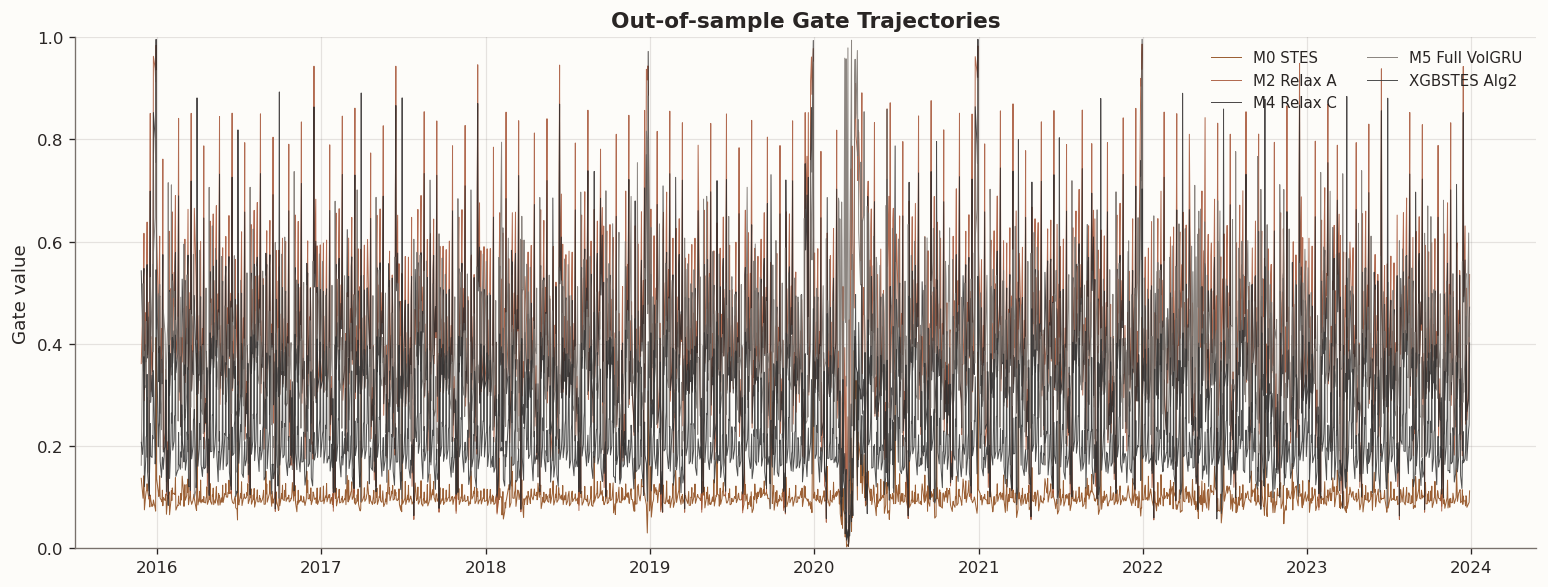

In [20]:
#| label: gate-diagnostics
#| code-fold: true
#| code-summary: "Gate summary table and trajectories"

gate_rows = []
for name, out in model_outputs.items():
    gate_os = np.asarray(out['gate_all'], dtype=float)[n_train:]
    sat_rate = np.mean((gate_os <= 0.05) | (gate_os >= 0.95))
    gate_rows.append(
        {
            'Model': name,
            'OS gate mean': float(np.mean(gate_os)),
            'OS gate std': float(np.std(gate_os)),
            'OS gate min': float(np.min(gate_os)),
            'OS gate max': float(np.max(gate_os)),
            'OS saturation rate': float(sat_rate),
        }
    )

gate_diag_table = pd.DataFrame(gate_rows)
display(style_results_table(gate_diag_table, precision=6, index_col='Model'))

# Trajectory figure for selected models
idx_os = X_all_s.index[n_train:]
plot_models = ['M0 STES', 'M2 Relax A', 'M4 Relax C', 'M5 Full VolGRU', 'XGBSTES Alg2']

fig, ax = plt.subplots(figsize=(13, 5))
color_map = {
    'M0 STES': BLOG_PALETTE[0],
    'M2 Relax A': BLOG_PALETTE[1],
    'M4 Relax C': BLOG_PALETTE[2],
    'M5 Full VolGRU': BLOG_PALETTE[3],
    'XGBSTES Alg2': '#333333',
}

for name in plot_models:
    gate_os = np.asarray(model_outputs[name]['gate_all'], dtype=float)[n_train:]
    ax.plot(idx_os, gate_os, linewidth=0.6, alpha=0.85, label=name, color=color_map[name])

ax.set_ylim(0, 1)
ax.set_ylabel('Gate value')
ax.set_title('Out-of-sample Gate Trajectories', fontsize=13, fontweight='bold')
ax.legend(ncol=2, fontsize=9)
fig.tight_layout()
plt.show()


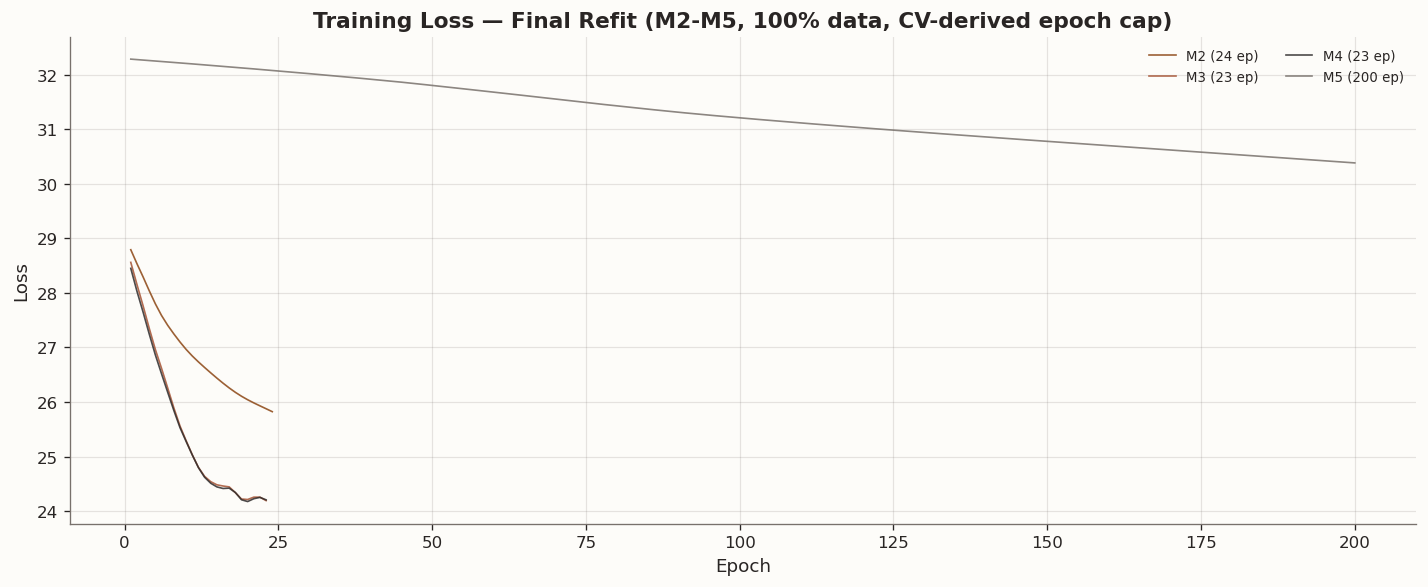

In [21]:
#| label: training-convergence
#| code-fold: true
#| code-summary: "Training loss convergence for M2-M5 (XGBoost-style refit)"

fig, ax = plt.subplots(figsize=(12, 5))
convergence_models = ['M2', 'M3', 'M4', 'M5']
colors_conv = {
    'M2': BLOG_PALETTE[0], 'M3': BLOG_PALETTE[1],
    'M4': BLOG_PALETTE[2], 'M5': BLOG_PALETTE[3],
}

for rung in convergence_models:
    hist = ladder_outputs[rung]['train_history']
    epochs = np.arange(1, len(hist) + 1)
    ax.plot(epochs, hist, linewidth=1.0, alpha=0.85,
            label=f'{rung} ({len(hist)} ep)', color=colors_conv[rung])

ax.set_xlabel('Epoch')
ax.set_ylabel('Loss')
ax.set_title('Training Loss — Final Refit (M2-M5, 100% data, CV-derived epoch cap)', fontsize=13, fontweight='bold')
ax.legend(fontsize=8, ncol=2)
fig.tight_layout()
plt.show()

## Statistical Tests

Diebold-Mariano comparisons are reported for squared-error loss and QLIKE loss. The first model in each pair is treated as model A.


In [22]:
#| label: dm-tests
#| code-fold: true
#| code-summary: "DM tests for M5 against STES/XGB and ladder steps"


def _sq_loss(y, yhat):
    y = np.asarray(y, dtype=float)
    yhat = np.asarray(yhat, dtype=float)
    return (y - yhat) ** 2


def _qlike_loss(y, yhat):
    y = np.maximum(np.asarray(y, dtype=float), 1e-20)
    yhat = np.maximum(np.asarray(yhat, dtype=float), 1e-20)
    ratio = y / yhat
    return ratio - np.log(ratio) - 1.0


pairs = [
    ('M5 vs STES', 'M5 Full VolGRU', 'M0 STES'),
    ('M5 vs XGBSTES', 'M5 Full VolGRU', 'XGBSTES Alg2'),
    ('M3 vs M2', 'M3 Relax B', 'M2 Relax A'),
    ('M4 vs M2', 'M4 Relax C', 'M2 Relax A'),
]

dm_rows = []
for label, a_name, b_name in pairs:
    pred_a = np.asarray(model_outputs[a_name]['sigma_all'], dtype=float)[n_train:]
    pred_b = np.asarray(model_outputs[b_name]['sigma_all'], dtype=float)[n_train:]

    res_sq = diebold_mariano(_sq_loss(actual_os, pred_a), _sq_loss(actual_os, pred_b), h=1)
    res_ql = diebold_mariano(_qlike_loss(actual_os, pred_a), _qlike_loss(actual_os, pred_b), h=1)

    dm_rows.append(
        {
            'Comparison': label,
            'DM (SE)': res_sq['dm_stat'],
            'p (SE)': res_sq['p_value'],
            'DM (QLIKE)': res_ql['dm_stat'],
            'p (QLIKE)': res_ql['p_value'],
            'Sig SE (5%)': 'Yes' if res_sq['p_value'] < 0.05 else 'No',
            'Sig QLIKE (5%)': 'Yes' if res_ql['p_value'] < 0.05 else 'No',
        }
    )

dm_table = pd.DataFrame(dm_rows)
print('Negative DM means model A has lower loss than model B.')
display(style_results_table(dm_table, precision=4, index_col='Comparison'))


Negative DM means model A has lower loss than model B.


,DM (SE),p (SE),DM (QLIKE),p (QLIKE),Sig SE (5%),Sig QLIKE (5%)
Comparison,,,,,,
M5 vs STES,1.4332,0.1519,2.8706,0.0041,No,Yes
M5 vs XGBSTES,1.2084,0.2270,1.1958,0.2319,No,No
M3 vs M2,0.5847,0.5588,-4.3004,0.0000,No,Yes
M4 vs M2,0.4890,0.6249,-4.0244,0.0001,No,Yes


## Validation Checks

This section enforces parity, numerical sanity, and a reproducibility check under fixed random seeds.


In [23]:
#| label: validation-checks
#| code-fold: true
#| code-summary: "Parity, finiteness, positivity, and reproducibility checks"

# 1) Data parity checks
assert PARITY_TICKER == 'SPY'
assert PARITY_SPLIT_INDEX == 4000
assert X_all_s.index.min() >= PARITY_START
assert X_all_s.index.max() <= PARITY_END + pd.Timedelta(days=5)

# 2) Shape, finiteness, positivity checks
for name, out in model_outputs.items():
    pred = np.asarray(out['sigma_all'], dtype=float)
    gate = np.asarray(out['gate_all'], dtype=float)
    assert pred.shape[0] == len(X_all_s), f'{name}: prediction length mismatch'
    assert gate.shape[0] == len(X_all_s), f'{name}: gate length mismatch'
    assert np.isfinite(pred).all(), f'{name}: non-finite predictions'
    assert np.isfinite(gate).all(), f'{name}: non-finite gates'
    assert np.min(pred) >= -1e-14, f'{name}: negative variance forecast'

# 3) Reproducibility check on M2
m2_cfg = copy.deepcopy(volgru_models['M2'].config)
m2_repro = VolGRUModel(config=m2_cfg, random_state=SEED)
m2_repro.fit(
    X_tr_s,
    y_tr_scaled,
    returns=r_tr_scaled,
    start_index=0,
    end_index=len(X_tr_s),
    beta_ref=np.asarray(stes_m0.params, dtype=float),
)
repro_sigma_scaled_all, repro_gate_all, _ = m2_repro.predict_with_gates(X_all_s, returns=r_all_scaled)
repro_sigma_all = np.asarray(repro_sigma_scaled_all, dtype=float) / (SCALE_FACTOR ** 2)

m2_os_rmse = rmse(actual_os, np.asarray(model_outputs['M2 Relax A']['sigma_all'])[n_train:])
repro_os_rmse = rmse(actual_os, repro_sigma_all[n_train:])
rmse_diff = float(abs(m2_os_rmse - repro_os_rmse))
assert rmse_diff < 1e-5, f'Reproducibility check failed with RMSE diff {rmse_diff}'

check_table = pd.DataFrame(
    {
        'Check': [
            'Data parity (ticker/split/date range)',
            'Shape/finiteness checks',
            'Positivity checks',
            'M2 reproducibility (OS RMSE diff)',
        ],
        'Status': ['Pass', 'Pass', 'Pass', 'Pass'],
        'Value': ['SPY / 4000 / parity range', 'All models finite', 'Min variance >= 0', f'{rmse_diff:.3e}'],
    }
)

display(style_results_table(check_table, precision=6, index_col='Check'))


,Status,Value
Check,,
Data parity (ticker/split/date range),Pass,SPY / 4000 / parity range
Shape/finiteness checks,Pass,All models finite
Positivity checks,Pass,Min variance >= 0
M2 reproducibility (OS RMSE diff),Pass,0.000e+00


## Discussion

The scalar ladder makes it fairly easy to see which relaxations add something and which mostly just add flexibility. All models were tuned with the same three-fold time-series CV protocol. In each fold, `val_fraction=0.15` determines both the best regularization setting and the average stopping epoch. The final refit then uses 100% of the training data with `val_fraction=0.0`, capped at the CV-derived epoch limit, so the final comparison keeps the same data visibility as STES.

**Candidate relaxation (M2).** Replacing the hard-coded candidate $\tilde{h}_t = r_t^2$ with a learnable linear positive transformation is the first scalar relaxation that clearly matters. CV again selects the strongest regularization tier (`weight_decay=0.01`, `beta_stay_close_lambda=0.05`, `gate_entropy_lambda=0.01`) and caps the refit at 24 epochs. M2 is the best-performing trainable VolGRU rung by RMSE, with OS RMSE = 0.000461 versus STES at 0.000473. But the gain is narrow and it comes with much worse proportional calibration: OS QLIKE rises to 1.80 from STES's 1.62.

**State-dependent gating (M3).** Letting the update gate observe the current scalar state adds a feedback loop that helps mainly under QLIKE. M3 reduces OS QLIKE from 1.80 to 1.76 relative to M2, and the DM test confirms that improvement is statistically significant under QLIKE (DM = -4.30, $p < 0.001$). But the same relaxation gives back the RMSE gain: OS RMSE widens to 0.000483. So state dependence helps distributional calibration relative to M2, but it still does not recover the STES benchmark under either loss.

**Reset gate (M4).** Adding a reset gate changes very little in a one-dimensional state space. M4 lands at OS RMSE = 0.000478 and OS QLIKE = 1.77, nearly identical to M3. In this scalar setting, the reset mechanism is mostly inert.

**MLP candidate (M5).** The nonlinear candidate is the most expressive specification in the scalar ladder, but it is also clearly the weakest rung. The refit runs for the full 200-epoch cap and ends at OS RMSE = 0.000524 and OS QLIKE = 1.85. The DM comparison against STES is insignificant under squared error ($p = 0.15$) but significantly worse under QLIKE ($p = 0.004$), so the richer candidate does not buy useful forecast flexibility in this single-asset setup.

**SE vs QLIKE divergence.** The tension between RMSE and QLIKE is sharp. M2 improves RMSE relative to STES while materially worsening QLIKE, and M3 partially repairs QLIKE relative to M2 while giving back the RMSE gain. The broader message is the same as in Part 4: the MSE training objective rewards point-forecast accuracy in variance levels, whereas QLIKE is more sensitive to proportional miscalibration. STES remains the strongest model in the scalar ladder by QLIKE, while XGBSTES remains the overall RMSE leader with OS RMSE = 0.000444.

**Training protocol.** The two-phase protocol matters because it removes the main apples-to-oranges objection. Scalar VolGRU sees the same augmented feature matrix and the same full training window during the final fit, so any remaining performance gap is about model structure rather than data visibility.

## Conclusion

The constrained VolGRU specification reproduces STES exactly under shared gate coefficients, so STES really is a strict special case of the one-dimensional VolGRU formulation studied here. Once that equivalence is in place, the scalar relaxation ladder reveals a clear split by loss function rather than a clear overall winner. The best trainable VolGRU rung by squared error is **M2**, with OS RMSE = 0.000461 versus 0.000473 for STES, but its OS QLIKE deteriorates sharply to 1.80. The best VolGRU rung by QLIKE is **M3**, which improves on M2 but still reaches only 1.76, well above STES at 1.62. The full nonlinear endpoint M5 is worse still, with OS RMSE = 0.000524 and OS QLIKE = 1.85.

The DM tests sharpen that picture. M3 and M4 are significantly better than M2 under QLIKE, but none of the trainable scalar VolGRU variants significantly improves on STES under squared-error loss. M5 is significantly worse than STES under QLIKE. Meanwhile, the benchmark XGBSTES model remains the strongest point-forecast competitor overall with OS RMSE = 0.000444, though it too trails STES on QLIKE.

So the main takeaway is not that VolGRU dominates STES. It is that relaxing STES within a one-dimensional hidden state does create useful flexibility, but the benefits are criterion-specific: a mild candidate relaxation can help RMSE, while state-dependent gating helps repair some of the QLIKE damage that follows. None of the tested scalar relaxations dominates the STES benchmark across both loss functions.

That leaves a natural next step. Part 7 will ask what changes when the latent state is no longer forced to be scalar. In other words, if Part 6 studies STES as a constrained one-dimensional GRU, the next post studies what becomes possible once VolGRU is allowed to keep a genuinely multi-dimensional hidden state.